In [1]:
from fiatlux.optical_elements.mask import CircularAperture
from fiatlux.grid import Grid
from fiatlux.spectrum import *
from fiatlux.source import *
from fiatlux.propagator import MFTPropagator, IdentityPropagator
from fiatlux.optical_elements.mask import ZeldaMask, ZeldaStop, ADC, TipTilt, Piston
from fiatlux.utils.converter import FocalPlaneConverter
from fiatlux.optical_elements.field_stop import ShanonFieldStop
from fiatlux.optical_system import SerialSystem
from fiatlux.detector import Detector
from fiatlux.optical_elements.deformable_mirror import (
    DeformableMirror,
    ActuatorGrid,
    InteractionMatrix,
    ZonalBasis,
)

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [ ]:
spectrum = Spectrum.from_sampling(magnitude=10, band=PhotometricBand.HCM, Nu=512)

# System parameters
f = 0.125
lambda_max = spectrum.wavelengths.max()
D = 1

tip = 0 * lambda_max / D
tilt = 1 * lambda_max / D


# Pupil plane sampling
Nx = Ny = 128
dx = dy = D / Nx
pupil_grid = Grid(nx=Nx, ny=Ny, dx=dx, dy=dx)

# Focal plane sampling
Nu = Nv = 512
# # Shanon
# du = dv = Nx * (f * l / D) / Nu
du = dv = (1) * (f * lambda_max / D) / (Nu / 2)
focal_grid = Grid(nx=Nu, ny=Nv, dx=du, dy=dv)

# Create source
source = PlaneWave(spectrum=spectrum)

# Empty propagator (for testing)
empty_propagator0 = IdentityPropagator(pupil_grid)
empty_propagator1 = IdentityPropagator(pupil_grid)

# Tip-tilt
tip_tilt = TipTilt(tip=tip, tilt=tilt)
piston = Piston(piston=0)


# Create aperture
aperture = CircularAperture(radius=D / 2)


# Define propagator
mft0 = MFTPropagator(focal_length=f, output_grid=focal_grid)
mft1 = MFTPropagator(focal_length=f, output_grid=pupil_grid)

stop = ShanonFieldStop()

theta = torch.as_tensor(lambda_max / 4)
# Define zelda mask
zelda_mask = ZeldaMask(radius=f * lambda_max / D, well_depth=theta)
zelda_stop = ZeldaStop(radius=f * lambda_max / D)

detector = Detector(
    grid=pupil_grid,
    photon_noise=True,
    readout_noise_variance=10,
    dark_current=10,
    offset=100,
)


actuator_grid = ActuatorGrid(n_actuators_x=10, n_actuators_y=10, pitch=D / 10)

basis = ZonalBasis(
    actuator_grid=actuator_grid,
    pixel_grid=pupil_grid,
    influence_width=D,
)
dm = DeformableMirror(
    actuator_grid=ActuatorGrid(n_actuators_x=10, n_actuators_y=10, pitch=D / 10),
    pixel_grid=pupil_grid,
    control_basis=basis,
    stroke=5e-6,
)

/var/folders/7t/065x1t751d328nctyly8v49r0000gn/T/ipykernel_85265/3271563385.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(lambda_max / 4)


/Users/pjanin/Documents/GitHub/fiatlux/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


0 PlaneWave()
1 IdentityPropagator(grid=Grid(nx=128, ny=128, dx=0.0078125, dy=0.0078125, device=device(type='cpu')))
2 TipTilt()
3 CircularAperture()
4 MFTPropagator(focal_length=0.125, output_grid=Grid(nx=512, ny=512, dx=tensor(5.9082e-10), dy=tensor(5.9082e-10), device=device(type='cpu')))
5 ShanonFieldStop()
6 MFTPropagator(focal_length=0.125, output_grid=Grid(nx=128, ny=128, dx=0.0078125, dy=0.0078125, device=device(type='cpu')))
7 IdentityPropagator(grid=Grid(nx=128, ny=128, dx=0.0078125, dy=0.0078125, device=device(type='cpu')))


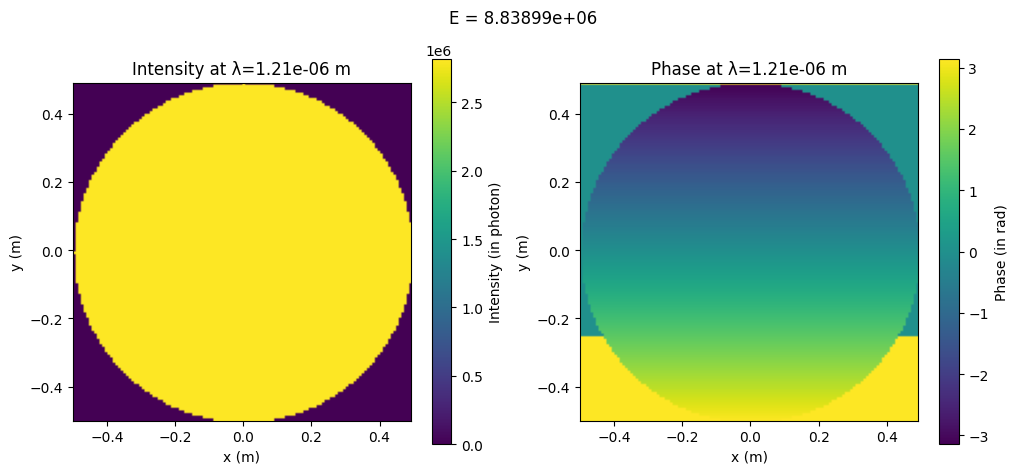

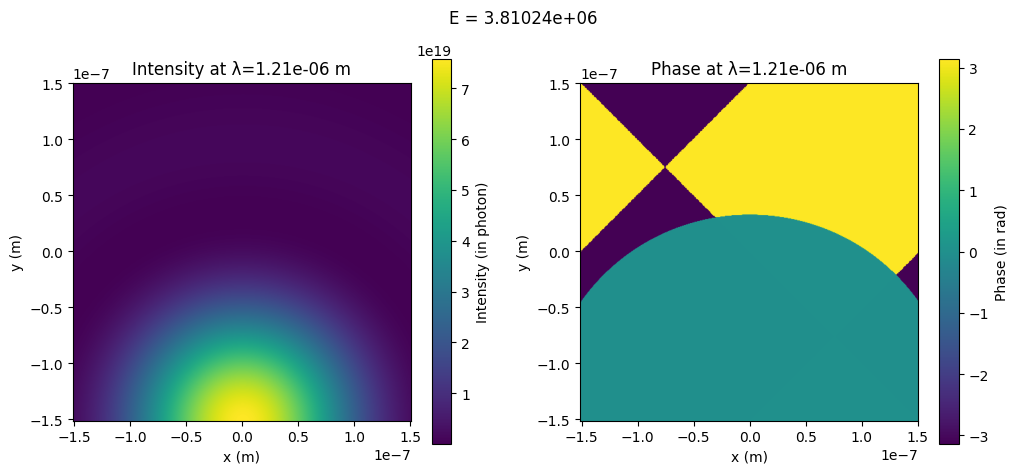

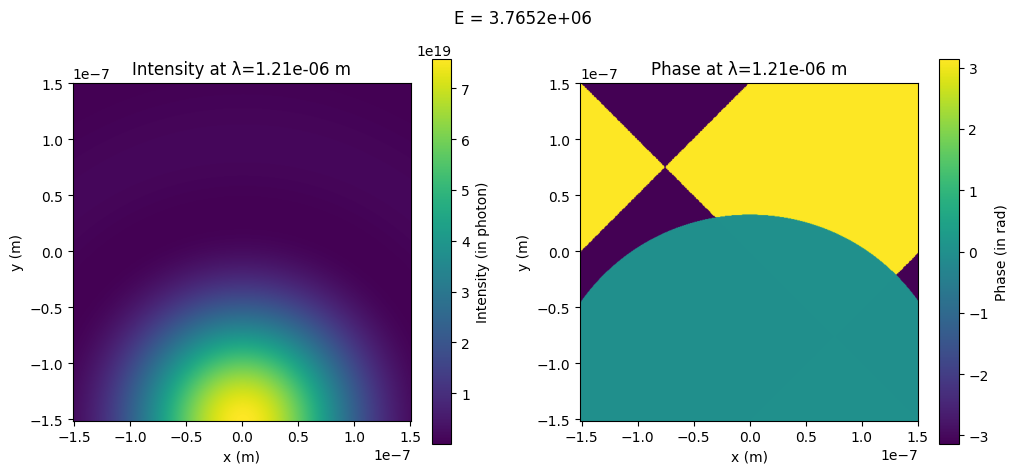

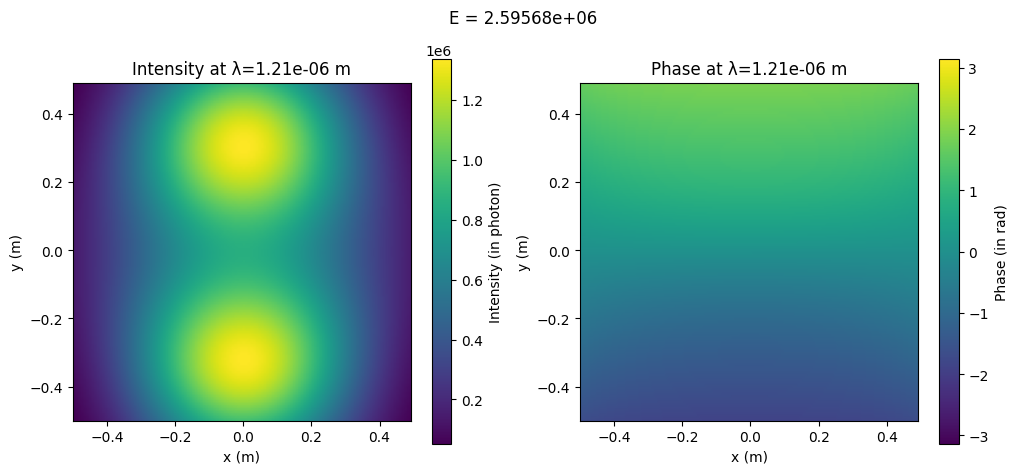

In [3]:
system = SerialSystem(
    source=source,
    detector=detector,
    elements=[
        empty_propagator0,
        tip_tilt,
        aperture,
        mft0,
        stop,
        mft1,
        empty_propagator1,
    ],
)
res = system.run()

for i in range(len(res.steps)):
    print(i, res.steps[i].element)

for i in [3, 4, 5, 7]:
    res.field_at(i).plot()
    plt.suptitle(
        f"E = {torch.sum(res.field_at(i).intensity() * res.field_at(i).grid.dx * res.field_at(i).grid.dy):2g}"
    )

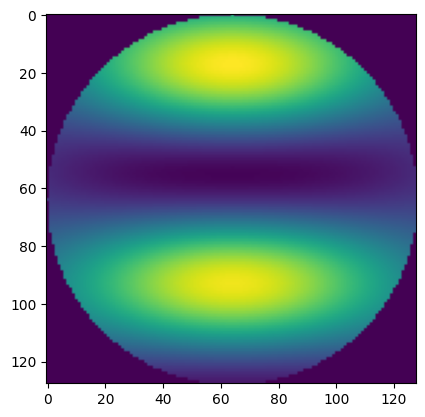

In [4]:
estimated_phase = aperture.apply(
    res.field_at(3)
    - (1 - torch.exp(1j * 2 * torch.pi * theta / lambda_max)) * res.field_at(-1)
).intensity()

estimated_phase = aperture.apply(
    (res.field_at(3) - res.field_at(-1))
    + torch.exp(1j * 2 * torch.pi * theta / lambda_max) * res.field_at(-1)
).intensity()

plt.imshow(estimated_phase[-1])

0 PlaneWave()
1 IdentityPropagator(grid=Grid(nx=128, ny=128, dx=0.0078125, dy=0.0078125, device=device(type='cpu')))
2 DeformableMirror()
3 CircularAperture()
4 MFTPropagator(focal_length=0.125, output_grid=Grid(nx=512, ny=512, dx=tensor(5.9082e-10), dy=tensor(5.9082e-10), device=device(type='cpu')))
5 ZeldaStop()
6 MFTPropagator(focal_length=0.125, output_grid=Grid(nx=128, ny=128, dx=0.0078125, dy=0.0078125, device=device(type='cpu')))
7 IdentityPropagator(grid=Grid(nx=128, ny=128, dx=0.0078125, dy=0.0078125, device=device(type='cpu')))


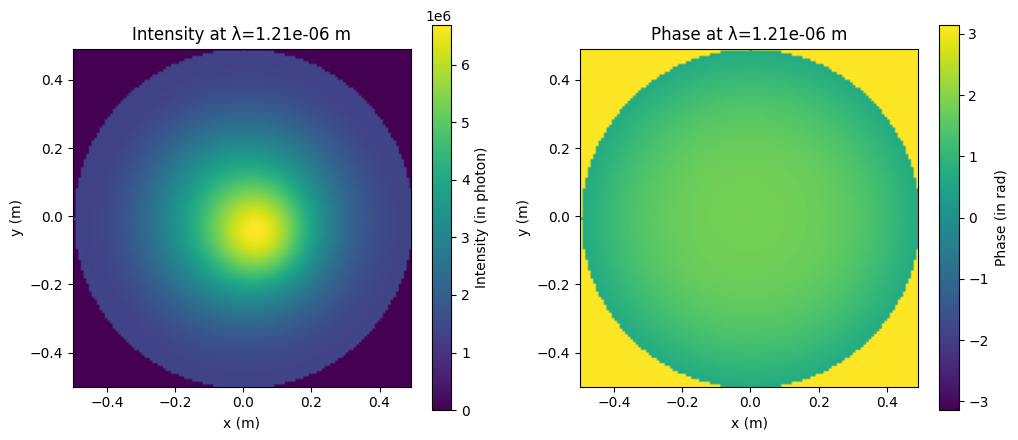

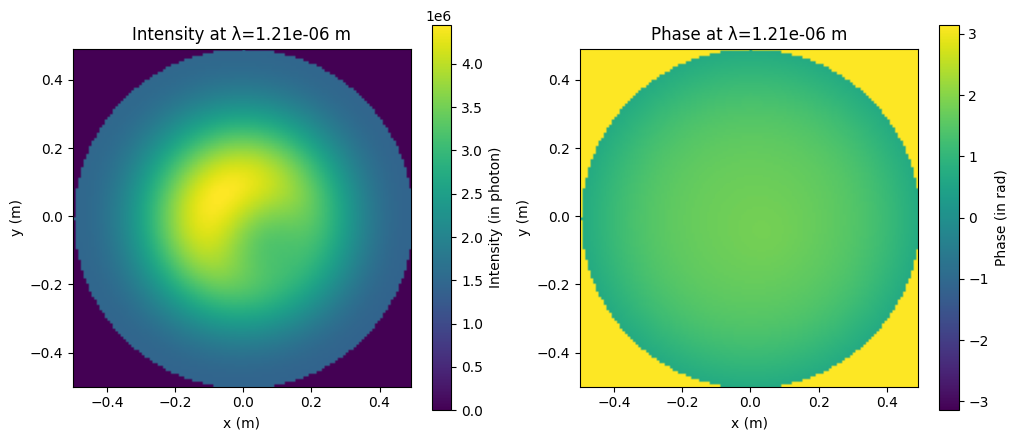

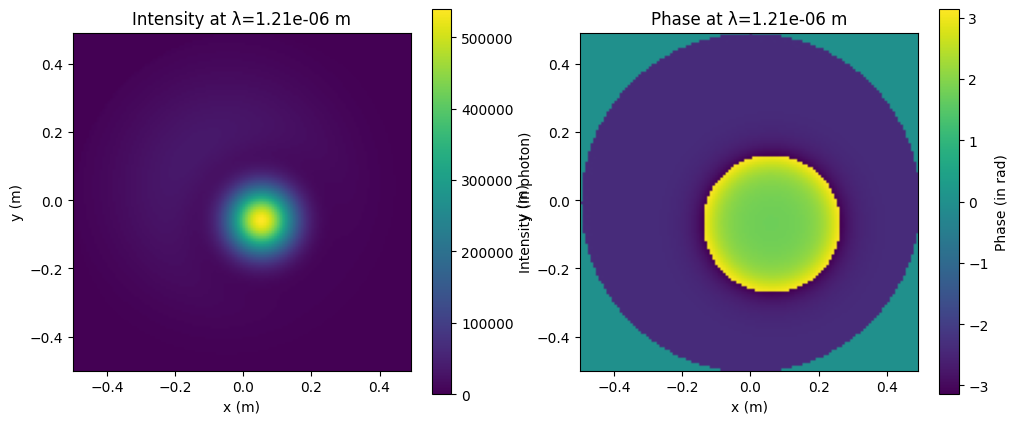

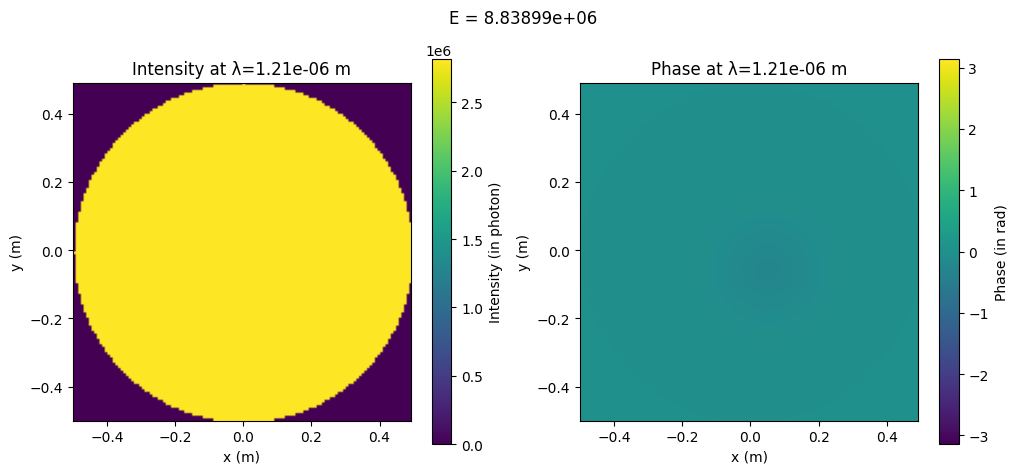

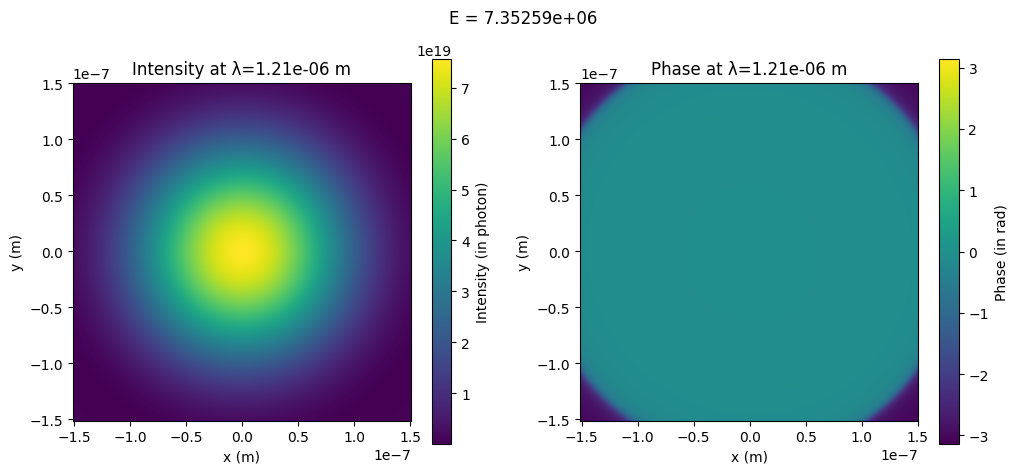

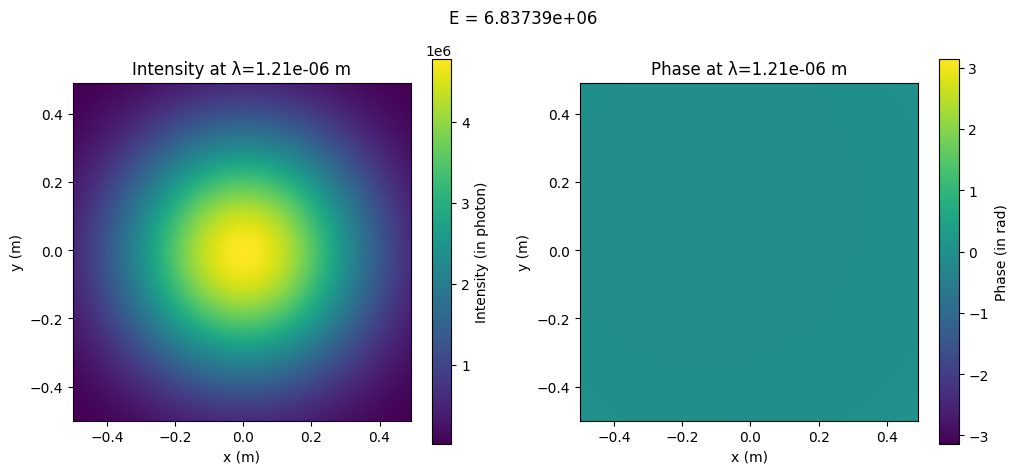

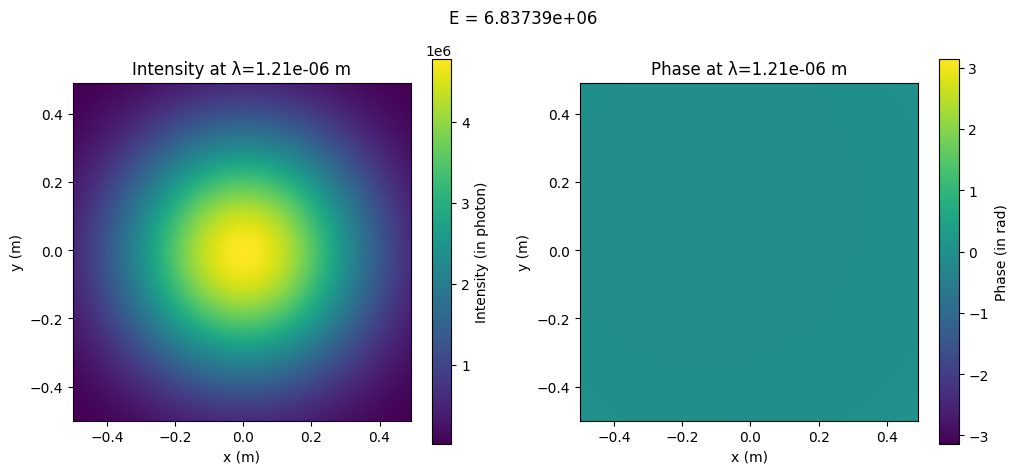

In [5]:
system = SerialSystem(
    source=source,
    detector=detector,
    elements=[
        empty_propagator0,
        dm,
        aperture,
        mft0,
        zelda_stop,
        mft1,
        empty_propagator1,
    ],
)

dm._commands.data = 0 * dm._commands.data
dm._commands.data[55] = 0.01
res = system.run()

push = aperture.apply(
    (res.field_at(3) - res.field_at(-1))
    + torch.exp(1j * 2 * torch.pi * theta / lambda_max) * res.field_at(-1)
)

push.plot()

dm._commands.data = 0 * dm._commands.data
dm._commands.data[55] = -0.01
res = system.run()

pull = aperture.apply(
    (res.field_at(3) - res.field_at(-1))
    + torch.exp(1j * 2 * torch.pi * theta / lambda_max) * res.field_at(-1)
)

pull.plot()

(push - pull).plot()


for i in range(len(res.steps)):
    print(i, res.steps[i].element)

for i in [3, 4, 6, 7]:
    res.field_at(i).plot()
    plt.suptitle(
        f"E = {torch.sum(res.field_at(i).intensity() * res.field_at(i).grid.dx * res.field_at(i).grid.dy):2g}"
    )

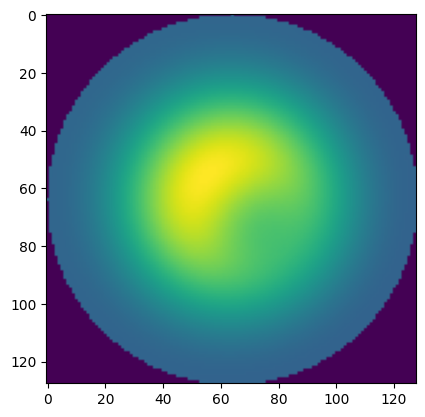

In [6]:
estimated_phase = aperture.apply(
    res.field_at(3)
    - (1 - torch.exp(1j * 2 * torch.pi * theta / lambda_max)) * res.field_at(-1)
).intensity()

estimated_phase = aperture.apply(
    (res.field_at(3) - res.field_at(-1))
    + torch.exp(1j * 2 * torch.pi * theta / lambda_max) * res.field_at(-1)
).intensity()

plt.imshow(estimated_phase[0])

In [7]:
dm._influence_matrix.shape

AttributeError: 'DeformableMirror' object has no attribute '_influence_matrix'

In [ ]:
system.elements[3].piston = 0
system.elements[3].recompute = True
res = system.run()
estimated_phase_0 = aperture.apply(
    res.field_at(4) - (1 - torch.exp(1j * theta)) * res.field_at(8)
)


system.elements[3].piston = lambda_max / 4
system.elements[3].recompute = True
res = system.run()
estimated_phase_1 = aperture.apply(
    res.field_at(4) - (1 - torch.exp(1j * theta)) * res.field_at(8)
)

IndexError: list index out of range

In [ ]:
plt.imshow(
    (
        (estimated_phase_1.intensity() - estimated_phase_0.intensity())
        / estimated_phase_0.intensity()
    )[3]
)
plt.colorbar()